# Single layer testing

This notebook tests the backend setup for a single layer.

In [1]:
# Documentation-specific setup, hidden from notebook output

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import seaborn as sns

sns.set_theme(style="ticks")

In [2]:
import eradiate
import matplotlib.pyplot as plt

import eradiate_disort as ed
from eradiate_disort.testing import TestMode, cases
from eradiate_disort.testing.util import Result, disort_reshape_pplane

eradiate.set_mode("ckd")

SPP = 1_000
PHASES = ["isotropic", "rayleigh"]

In [3]:
# Dev-specific setup, hidden from notebook output

plt = TestMode.plt()
_base_spp = TestMode.spp(tutorial=1_000, test=10_000)
SPP = _base_spp // 16 if eradiate.get_mode().is_ckd else _base_spp

In [4]:
results = {}

for phase in PHASES:
    result = Result()

    exp = cases.single_layer(30.0, phase, backend="mitsuba")
    result.mitsuba = eradiate.run(exp, spp=SPP)["radiance"].squeeze()

    exp = cases.single_layer(30.0, phase, backend="disort")
    backend = ed.DisortBackend()
    result.disort = disort_reshape_pplane(backend.run(exp).sel(z=1000.0))

    results[phase] = result

0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

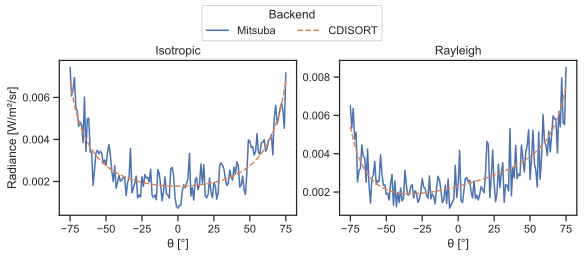

In [5]:
def plot(results):
    fig, axs = plt.subplots(1, len(results), figsize=(8, 3.5), layout="constrained")

    for k, phase in enumerate(results.keys()):
        ax = axs[k]
        result = results[phase]

        ax.plot(
            result.mitsuba["vza"],
            result.mitsuba,
            label="Mitsuba" if k == 0 else None,
        )
        ax.plot(
            result.disort["vza"],
            result.disort,
            label="CDISORT" if k == 0 else None,
            ls="--",
        )

        ax.set_xlabel("θ [°]")
        ax.set_ylabel("Radiance [W/m²/sr]" if k == 0 else None)
        ax.set_title(phase.title())

    fig.legend(title="Backend", loc="outside upper center", ncol=2)

    return fig, axs


plot(results)
plt.show()
plt.close()

In [6]:
import attrs
from eradiate.xarray import unstack_mdistant_grid

results = {}

for phase in ["rayleigh"]:
    result = Result()

    exp = attrs.evolve(
        cases.single_layer(30.0, phase, backend="mitsuba"),
        measures=cases._grid_measure(backend="mitsuba"),
    )
    result.mitsuba = unstack_mdistant_grid(
        eradiate.run(exp, spp=SPP)["radiance"]
    ).squeeze()

    exp = attrs.evolve(
        cases.single_layer(30.0, phase, backend="disort"),
        measures=cases._grid_measure(backend="disort"),
    )
    backend = ed.DisortBackend()
    result.disort = backend.run(exp)["measure/uu"].sel(z=1000.0).squeeze().sortby("vza")

    results[phase] = result

0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

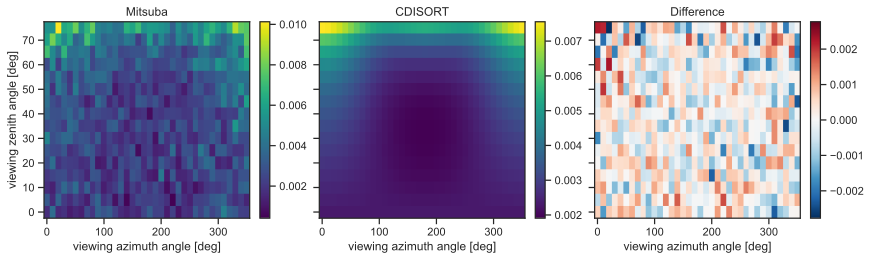

In [7]:
def plot(results):
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.5), layout="constrained", sharey=True)

    ax = axs[0]
    results["rayleigh"].mitsuba.plot.imshow(ax=ax, cbar_kwargs={"label": None})
    ax.set_title("Mitsuba")

    ax = axs[1]
    results["rayleigh"].disort.plot.imshow(ax=ax, cbar_kwargs={"label": None})
    ax.set_title("CDISORT")
    ax.set_ylabel(None)

    ax = axs[2]
    (
        (result.disort.assign_coords({k: result.mitsuba[k] for k in ["vza", "vaa"]}))
        - result.mitsuba
    ).plot.imshow(ax=ax)
    ax.set_title("Difference")
    ax.set_ylabel(None)

    return fig, axs


plot(results)
plt.show()
plt.close()